# 🚗 Project 5: Used Car Price Prediction & Valuation Engine
### Multiple Linear Regression, Log Elasticity & High-Cardinality Engineering

In this project, we build an end-to-end Machine Learning valuation system for used cars in the automotive market. We tackle real-world data engineering challenges including **dirty strings containing text units (`Tk`, `cc`, `km`)**, **multi-label fuel capabilities**, and **high cardinality brands/models**.

---

### 🎯 Business Objective
As a Lead Machine Learning Engineer for an online automobile marketplace:
1. **Accurate Valuation**: Build a predictive regression model to estimate fair market value (`price`) based on vehicle specifications.
2. **Handle Domain Complexity**:
   - Clean dirty string units (`"Tk 530,000"`, `"1,500 cc"`, `"89,000 km"`).
   - Engineer multi-label binary fuel flags from comma-separated strings (`"CNG, Octane"`, `"Petrol, Hybrid, Octane"`).
   - Overcome high-cardinality trap in `brand` (33 brands, 88.5% Toyota) and `model` (168 models) using Top-K and Luxury flags.
3. **Log-Target Transformation**: Mitigate heavy right-skewed pricing (standard commuter cars vs. multi-crore luxury vehicles).
4. **Deploy & Persist**: Export a production-ready valuation model (`car_price_model.pkl`).

---

### 🧭 Universal 6-Step Workflow
1. **Data Ingestion**: Load and inspect dataset schema.
2. **D-M-D-T-O EDA & Cleaning**:
   - **[D]**: Convert fake string columns (`price`, `energy_capacity`, `kilometers_run`) to numeric floats.
   - **[M]**: Audit missing values.
   - **[D]**: Audit duplicates.
   - **[T]**: Target distribution, 5-point summary, and Log-Transformation analysis.
   - **[O]**: Outliers & Bivariate correlation analysis (trendlines & heatmap).
3. **Feature Engineering & Encoding**:
   - `is_luxury` binary flag for premium marques.
   - `brand` Top-5 One-Hot encoding.
   - `fuel_type` Multi-label one-hot decomposition (`.str.get_dummies()`).
   - `transmission` binary indicator.
4. **Train-Test Split**: 80% Train, 20% Test with reproducibility seed.
5. **Model Training & Benchmarks**: OLS Linear Regression (Raw vs. Log-Transformed) + Ridge & Lasso.
6. **Diagnostics & Business Insights**: Residual checks, feature importance ranking, live valuation simulation, and model export.

---
## 📥 Step 1: Environment Setup & Library Imports

In [193]:
import os
import shutil
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import joblib

# Scikit-learn modeling & evaluation
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Plotting configuration
plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")
print("✅ Core scientific and machine learning libraries successfully loaded!")

✅ Core scientific and machine learning libraries successfully loaded!


---
## 📂 Step 2: Data Ingestion & Initial Inspection

In [194]:
# Load UsedCarInfo dataset
csv_path = Path("data/used_car/UsedCarInfo.csv")
if not csv_path.exists():
    # Fallback to absolute or search path
    csv_path = Path("supervised_learning/LinearRegression/data/used_car/UsedCarInfo.csv")

df = pd.read_csv(csv_path)

print("=" * 50)
print(f"✅ Dataset loaded successfully: {csv_path.name}")
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print("=" * 50)
df.head(5)

✅ Dataset loaded successfully: UsedCarInfo.csv
Shape: 5,997 rows × 10 columns


,title,brand,model,transmission,fuel_type,price,year_of_manufacture,energy_capacity,kilometers_run,car_age
0,Toyota Corolla CR 13.REG 1999.MODEL 1996,Toyota,Corolla,Automatic,"CNG, Octane","Tk 530,000",1996,"1,500 cc","89,000 km",30
1,Toyota Corolla Cross 2023,Toyota,Corolla Cross,Automatic,"Hybrid, Octane","Tk 5,500,000",2025,"1,800 cc","15,500 km",1
2,Toyota RAV4 CR 13.REG 2011.MODEL 2005,Toyota,RAV4,Automatic,"Octane, LPG","Tk 1,370,000",2005,"1,800 cc","87,000 km",21
3,Toyota Allion CR 23.REG 2010.MODEL 2004,Toyota,Allion,Automatic,"CNG, Octane","Tk 1,350,000",2004,"1,500 cc","89,000 km",22
4,Toyota Hiace 2015,Toyota,Hiace,Automatic,"CNG, Octane","Tk 2,750,000",2020,"2,000 cc","190,000 km",6


---
## 🔍 Step 3: Exploratory Data Analysis & The D-M-D-T-O Framework

We systematically audit and clean the dataset:
- **D** - Data Types & String-Unit Cleaning
- **M** - Missing Values Audit
- **D** - Duplicate Rows Check
- **T** - Target Variable Analysis (`price`)
- **O** - Outliers & Bivariate Analysis

### [D] Data Types Audit & "Fake String" Cleaning
Notice that columns `price` (e.g. `"Tk 530,000"`), `energy_capacity` (e.g. `"1,500 cc"`), and `kilometers_run` (e.g. `"89,000 km"`) contain numbers mixed with text and commas. We systematically strip units and cast them to proper numerical floats.

In [195]:
import re
# Raw data types breakdown
print("--- Raw Data Types ---")
print(df.dtypes)

# 1. Clean Target Column: 'price' (Strip 'Tk', commas, whitespace)
df["price"] = (
    df["price"]
    .astype(str)
    .str.replace("Tk", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.strip()
    .astype(float)
)

# 2. Clean 'energy_capacity': Extract digits before 'cc' (robust to dirty data rows)
df["energy_capacity"] = (
    df["energy_capacity"]
    .astype(str)
    .str.extract(r"([\d,]+)\s*cc", flags=re.IGNORECASE if "re" in globals() else 0)[0]
    .str.replace(",", "", regex=False)
    .astype(float)
)

# 3. Clean 'kilometers_run': Extract digits before 'km'
df["kilometers_run"] = (
    df["kilometers_run"]
    .astype(str)
    .str.extract(r"([\d,]+)\s*km", flags=re.IGNORECASE if "re" in globals() else 0)[0]
    .str.replace(",", "", regex=False)
    .astype(float)
)

print("\n" + "=" * 50)
print("✅ Converted Fake Strings to Clean Numeric Floats:")
print(f"- price:           {df['price'].dtype}")
print(f"- energy_capacity: {df['energy_capacity'].dtype}")
print(f"- kilometers_run:  {df['kilometers_run'].dtype}")
print("=" * 50)

--- Raw Data Types ---
title                    str
brand                    str
model                    str
transmission             str
fuel_type                str
price                    str
year_of_manufacture    int64
energy_capacity          str
kilometers_run           str
car_age                int64
dtype: object

✅ Converted Fake Strings to Clean Numeric Floats:
- price:           float64
- energy_capacity: float64
- kilometers_run:  float64


In [196]:
# [M] Missing Values Audit
null_counts = df.isnull().sum()
missing_cols = null_counts[null_counts > 0]

if len(missing_cols) > 0:
    print(f"⚠️ Missing values detected:\n{missing_cols}")
else:
    print("✅ Clean Data: Zero missing values detected across all columns!")

✅ Clean Data: Zero missing values detected across all columns!


In [197]:
# [D] Duplicate Rows Audit
dup_count = df.duplicated().sum()
print(f"--- [D] Duplicate Rows Count: {dup_count} ---")
if dup_count > 0:
    print(f"⚠️ {dup_count} duplicate rows found ({dup_count/len(df)*100:.2f}%).")
else:
    print("✅ Clean Data: Zero duplicate rows detected.")

--- [D] Duplicate Rows Count: 0 ---
✅ Clean Data: Zero duplicate rows detected.


### [T] Target Variable Analysis (`price`)
We compute the 5-point summary and analyze skewness. Used car prices typically exhibit an extreme right tail due to luxury vehicles.

--- 5-Point Summary of Car Price (in Taka) ---
count          Tk 5,997.00
mean       Tk 4,076,050.26
std        Tk 4,973,530.11
min           Tk 46,189.00
25%        Tk 2,349,999.00
50%        Tk 3,380,000.00
75%        Tk 4,400,000.00
max      Tk 105,000,000.00
Name: price, dtype: str

Skewness: 9.6214 (Severe Right Skew > 1.0 indicates exponential price distribution)


/tmp/ipykernel_2152287/2700822847.py:18: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot(df["price"], vert=False, patch_artist=True, boxprops=dict(facecolor="#ff7f0e", alpha=0.6))


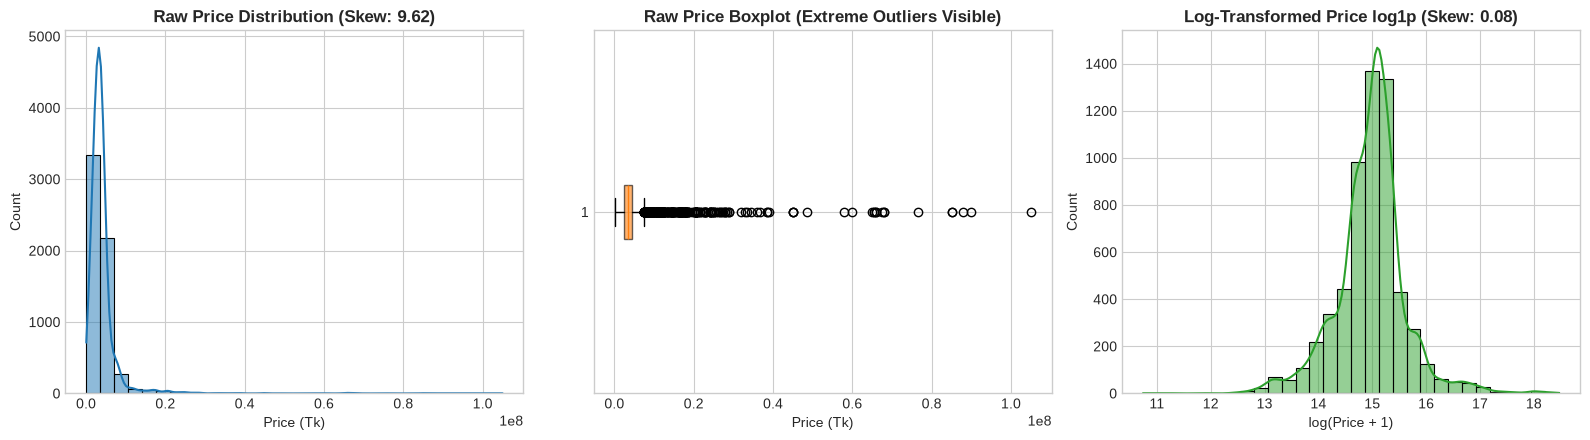

In [198]:
# [T] 5-Point Summary and Skewness
price_stats = df["price"].describe()
price_skew = df["price"].skew()

print("--- 5-Point Summary of Car Price (in Taka) ---")
print(price_stats.apply(lambda x: f"Tk {x:,.2f}"))
print(f"\nSkewness: {price_skew:.4f} (Severe Right Skew > 1.0 indicates exponential price distribution)")

# 3-Panel Visual Diagnostics: Raw vs. Log-Transformed
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# 1. Raw Price Histogram
sns.histplot(df["price"], bins=30, kde=True, ax=axes[0], color="#1f77b4")
axes[0].set_title(f"Raw Price Distribution (Skew: {price_skew:.2f})", fontweight="bold")
axes[0].set_xlabel("Price (Tk)")

# 2. Raw Price Boxplot
axes[1].boxplot(df["price"], vert=False, patch_artist=True, boxprops=dict(facecolor="#ff7f0e", alpha=0.6))
axes[1].set_title("Raw Price Boxplot (Extreme Outliers Visible)", fontweight="bold")
axes[1].set_xlabel("Price (Tk)")

# 3. Log-Transformed Price Histogram (Normalizing the target!)
log_price = np.log1p(df["price"])
sns.histplot(log_price, bins=30, kde=True, ax=axes[2], color="#2ca02c")
axes[2].set_title(f"Log-Transformed Price log1p (Skew: {log_price.skew():.2f})", fontweight="bold")
axes[2].set_xlabel("log(Price + 1)")

plt.tight_layout()
plt.show()

### [O] Outliers & Bivariate Analysis
We calculate the IQR outlier boundaries for `price` and plot bivariate relationships between key numeric predictors and price.

IQR Upper Threshold: Tk 7,475,002
Outlier Cars (High-End / Luxury): 429 (7.15%)


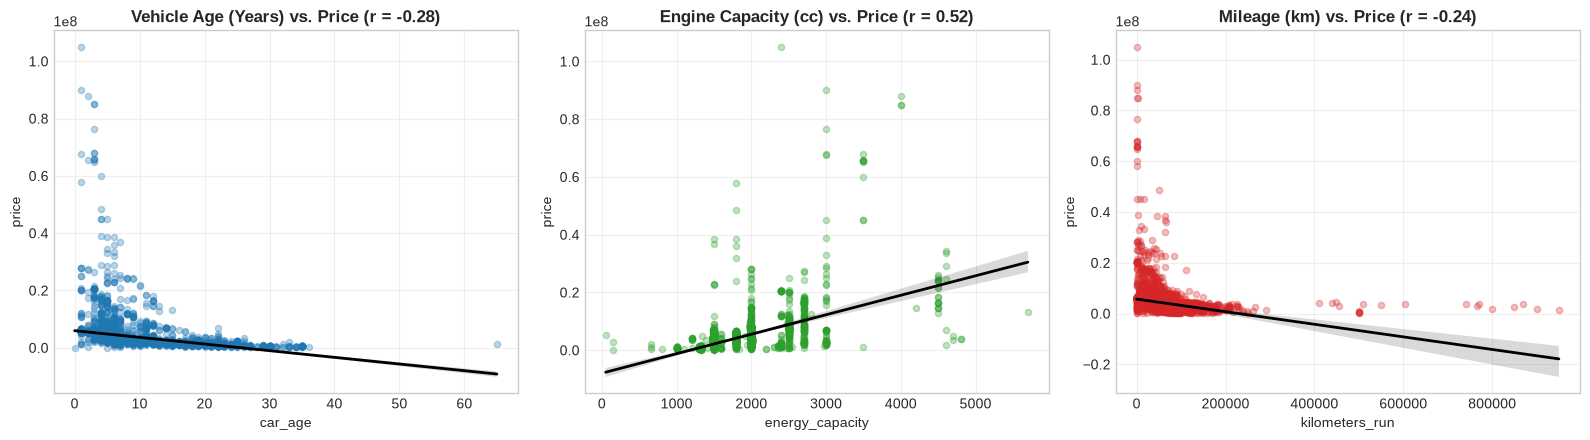

In [199]:
# 1. IQR Outlier Calculation on Raw Price
Q1 = df["price"].quantile(0.25)
Q3 = df["price"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outlier_count = ((df["price"] < lower_bound) | (df["price"] > upper_bound)).sum()
print(f"IQR Upper Threshold: Tk {upper_bound:,.0f}")
print(f"Outlier Cars (High-End / Luxury): {outlier_count} ({outlier_count/len(df)*100:.2f}%)")

# 2. Bivariate Scatter Plots with Trendlines
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

features_to_plot = [
    ("car_age", "Vehicle Age (Years)", "#1f77b4"),
    ("energy_capacity", "Engine Capacity (cc)", "#2ca02c"),
    ("kilometers_run", "Mileage (km)", "#d62728")
]

for idx, (col, label, colr) in enumerate(features_to_plot):
    sns.regplot(data=df, x=col, y="price", ax=axes[idx],
                scatter_kws={"alpha": 0.3, "color": colr, "s": 20},
                line_kws={"color": "black", "linewidth": 2})
    r_val = df[col].corr(df["price"])
    axes[idx].set_title(f"{label} vs. Price (r = {r_val:.2f})", fontweight="bold")
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## ⚙️ Step 4: Feature Engineering & Categorical Encoding

We apply data-driven encoding strategies:
1. **`is_luxury` Flag**: Distinguish ultra-premium marques (BMW, Mercedes, Audi, Lexus, Range Rover) from commuter vehicles.
2. **Top-5 Brand One-Hot**: Preserve the top 5 marques (`Toyota`, `Honda`, `Nissan`, `Mitsubishi`, `Lexus`) and group the long tail into `Other`.
3. **Multi-Label Fuel Type Deconstruction**: Decompose comma-separated fuels (`"CNG, Octane"`, `"Hybrid, Octane"`) into separate binary flags using `.str.get_dummies()`.
4. **Binary Transmission**: Convert `transmission` into `is_automatic`.
5. **Drop High-Cardinality & Redundant Columns**: Remove `title` and `model` (168 categories) to prevent curse of dimensionality.

In [200]:
# 1. Feature Engineering: Luxury Brand Indicator
luxury_brands = [
    "BMW", "Mercedes-Benz", "Audi", "Lexus", "Range Rover", 
    "Jaguar", "Land Rover", "Rolls Royce", "Volvo"
]
df["is_luxury"] = df["brand"].isin(luxury_brands).astype(int)

lux_comparison = df.groupby("is_luxury")["price"].agg(["count", "mean", "median"])
lux_comparison["mean"] = lux_comparison["mean"].apply(lambda x: f"Tk {x:,.0f}")
lux_comparison["median"] = lux_comparison["median"].apply(lambda x: f"Tk {x:,.0f}")
print("--- Luxury vs. Non-Luxury Market Price Benchmark ---")
print(lux_comparison)

# 2. Categorical: Top-5 Brand One-Hot Encoding
top_5_brands = df["brand"].value_counts().nlargest(5).index
df["brand_clean"] = df["brand"].apply(lambda x: x if x in top_5_brands else "Other")
brand_dummies = pd.get_dummies(df["brand_clean"], prefix="brand", drop_first=True, dtype=int)

# 3. Multi-Label Categorical: Fuel Type Deconstruction
fuel_dummies = df["fuel_type"].str.get_dummies(sep=", ").add_prefix("fuel_")

# 4. Binary Categorical: Transmission Flag
is_automatic = (df["transmission"] == "Automatic").astype(int)

# 5. Assemble Master Engineered DataFrame
df_encoded = pd.concat([
    df[["price", "year_of_manufacture", "car_age", "energy_capacity", "kilometers_run", "is_luxury"]],
    brand_dummies,
    fuel_dummies
], axis=1)

df_encoded["is_automatic"] = is_automatic

print("\n" + "=" * 50)
print(f"✅ Feature Engineering Complete! Processed Shape: {df_encoded.shape}")
print("Total Features:", len(df_encoded.columns) - 1)
print("=" * 50)
df_encoded.head(3)

--- Luxury vs. Non-Luxury Market Price Benchmark ---
           count           mean         median
is_luxury                                     
0           5877   Tk 3,724,256   Tk 3,350,000
1            120  Tk 21,305,167  Tk 14,100,000

✅ Feature Engineering Complete! Processed Shape: (5997, 21)
Total Features: 20


,price,year_of_manufacture,car_age,energy_capacity,kilometers_run,is_luxury,brand_Lexus,brand_Mitsubishi,brand_Nissan,brand_Other,...,fuel_CNG,fuel_Diesel,fuel_Electric,fuel_Hybrid,fuel_LPG,fuel_Octane,fuel_Other fuel type,fuel_Petrol,fuel_Unknown,is_automatic
0,530000.0,1996,30,1500.0,89000.0,0,0,0,0,0,...,1,0,0,0,0,1,0,0,0,1
1,5500000.0,2025,1,1800.0,15500.0,0,0,0,0,0,...,0,0,0,1,0,1,0,0,0,1
2,1370000.0,2005,21,1800.0,87000.0,0,0,0,0,0,...,0,0,0,0,1,1,0,0,0,1


In [202]:
df_encoded.columns


Index(['price', 'year_of_manufacture', 'car_age', 'energy_capacity',
       'kilometers_run', 'is_luxury', 'brand_Lexus', 'brand_Mitsubishi',
       'brand_Nissan', 'brand_Other', 'brand_Toyota', 'fuel_CNG',
       'fuel_Diesel', 'fuel_Electric', 'fuel_Hybrid', 'fuel_LPG',
       'fuel_Octane', 'fuel_Other fuel type', 'fuel_Petrol', 'fuel_Unknown',
       'is_automatic'],
      dtype='str')

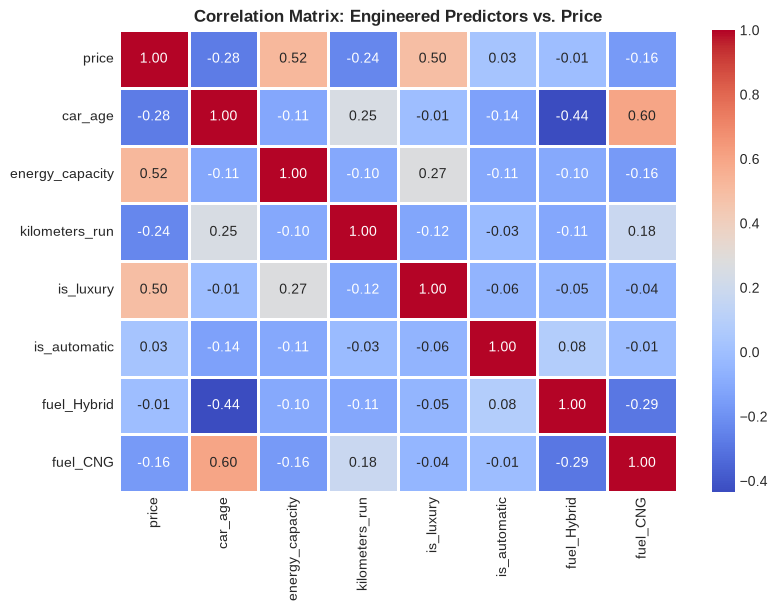

In [9]:
# Correlation Matrix of Core Features with Price
core_cols = ["price", "car_age", "energy_capacity", "kilometers_run", "is_luxury", "is_automatic", "fuel_Hybrid", "fuel_CNG"]
corr_core = df_encoded[core_cols].corr()

plt.figure(figsize=(9, 6))
sns.heatmap(corr_core, annot=True, cmap="coolwarm", fmt=".2f", linewidths=1)
plt.title("Correlation Matrix: Engineered Predictors vs. Price", fontsize=12, fontweight="bold")
plt.show()

---
## 🏋️ Step 5: Train-Test Split (80% Train, 20% Validation)

To properly evaluate predictive performance and prevent data leakage, we allocate 80% for training and reserve 20% for test validation. We also prepare the **log-transformed target** `y_log = np.log1p(y)`.

In [ ]:
# Feature Matrix (X) and Targets (y and y_log)
X = df_encoded.drop(columns=["price"])
y = df_encoded["price"]
y_log = np.log1p(y)

# 80/20 Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Parallel split for log target
_, _, y_log_train, y_log_test = train_test_split(
    X, y_log, test_size=0.2, random_state=42
)

print(f"✅ Total Observations:  {len(X):,}")
print(f"🏋️ Training Records:    {X_train.shape[0]:,} (80%)")
print(f"🧪 Testing Records:     {X_test.shape[0]:,} (20%)")
print(f"📐 Features Count:      {X_train.shape[1]}")

✅ Total Observations: 5,997
🏋️ Training Records:    4,797 (80%)
🧪 Testing Records:     1,200 (20%)
📐 Features Count:      20


---
## 🧠 Step 6: Model Training & Comparative Benchmarking

We evaluate:
1. **Model A: OLS on Raw Price**
2. **Model B: OLS on Log-Transformed Price (`log1p`)**
3. **Model C: Ridge Regression ($L_2$) on Log-Price**
4. **Model D: Lasso Regression ($L_1$) on Log-Price**

In [11]:
# Model A: Raw Price OLS
model_raw = LinearRegression().fit(X_train, y_train)
y_pred_raw = model_raw.predict(X_test)

# Model B: Log-Transformed Price OLS
model_log = LinearRegression().fit(X_train, y_log_train)
y_pred_log = model_log.predict(X_test)
y_pred_log_back = np.expm1(y_pred_log)  # Invert back to natural Taka currency

# Model C: Ridge (L2) on Log-Price
model_ridge = Ridge(alpha=1.0).fit(X_train, y_log_train)
y_pred_ridge = np.expm1(model_ridge.predict(X_test))

# Model D: Lasso (L1) on Log-Price
model_lasso = Lasso(alpha=0.001).fit(X_train, y_log_train)
y_pred_lasso = np.expm1(model_lasso.predict(X_test))

# Performance Summary Table (Computed on Real Taka Currency)
benchmark_df = pd.DataFrame({
    "Model Architecture": [
        "Linear Regression (Raw Price)",
        "Linear Regression (Log Price)",
        "Ridge Regression (Log Price, α=1.0)",
        "Lasso Regression (Log Price, α=0.001)"
    ],
    "R² Score (Test Scale)": [
        r2_score(y_test, y_pred_raw),
        r2_score(y_log_test, y_pred_log),
        r2_score(y_log_test, model_ridge.predict(X_test)),
        r2_score(y_log_test, model_lasso.predict(X_test))
    ],
    "Test MAE (in Taka)": [
        mean_absolute_error(y_test, y_pred_raw),
        mean_absolute_error(y_test, y_pred_log_back),
        mean_absolute_error(y_test, y_pred_ridge),
        mean_absolute_error(y_test, y_pred_lasso)
    ],
    "Test RMSE (in Taka)": [
        np.sqrt(mean_squared_error(y_test, y_pred_raw)),
        np.sqrt(mean_squared_error(y_test, y_pred_log_back)),
        np.sqrt(mean_squared_error(y_test, y_pred_ridge)),
        np.sqrt(mean_squared_error(y_test, y_pred_lasso))
    ]
})

print("=" * 60)
print(" 📊 COMPARATIVE MODEL BENCHMARK TABLE")
print("=" * 60)
benchmark_df["Test MAE (in Taka)"] = benchmark_df["Test MAE (in Taka)"].apply(lambda x: f"Tk {x:,.0f}")
benchmark_df["Test RMSE (in Taka)"] = benchmark_df["Test RMSE (in Taka)"].apply(lambda x: f"Tk {x:,.0f}")
benchmark_df["R² Score (Test Scale)"] = benchmark_df["R² Score (Test Scale)"].round(4)
print(benchmark_df.to_string(index=False))
print("=" * 60)

 📊 COMPARATIVE MODEL BENCHMARK TABLE
                   Model Architecture  R² Score (Test Scale) Test MAE (in Taka) Test RMSE (in Taka)
        Linear Regression (Raw Price)                 0.4366       Tk 1,540,382        Tk 4,333,478
        Linear Regression (Log Price)                 0.7850       Tk 1,158,080        Tk 3,947,642
  Ridge Regression (Log Price, α=1.0)                 0.8041       Tk 1,078,697        Tk 3,270,364
Lasso Regression (Log Price, α=0.001)                 0.7938       Tk 1,130,594        Tk 3,778,742


---
## 📈 Step 7: Diagnostic Visualizations (Actual vs. Predicted & Residuals)

We validate model reliability using the best-performing log-transformed linear regression model.

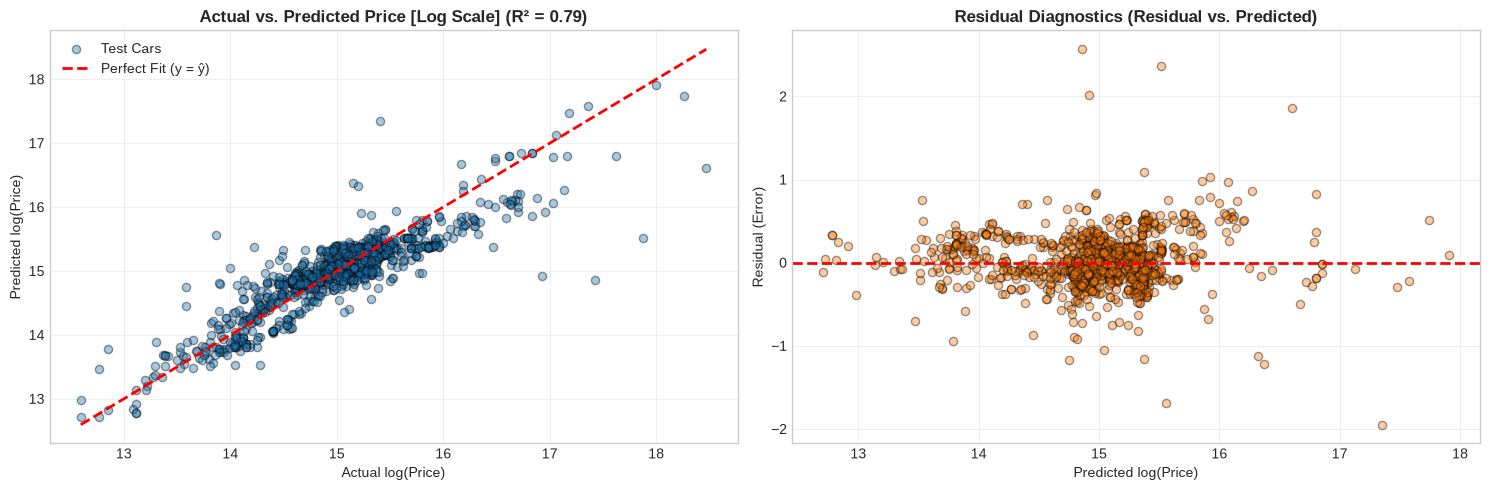

In [12]:
residuals_log = y_log_test - y_pred_log

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 1. Actual vs Predicted (Log Scale)
axes[0].scatter(y_log_test, y_pred_log, color="#1f77b4", alpha=0.4, edgecolors="k", s=35, label="Test Cars")
min_val = min(y_log_test.min(), y_pred_log.min())
max_val = max(y_log_test.max(), y_pred_log.max())
axes[0].plot([min_val, max_val], [min_val, max_val], color="red", linestyle="--", linewidth=2, label="Perfect Fit (y = ŷ)")
axes[0].set_title(f"Actual vs. Predicted Price [Log Scale] (R² = {r2_score(y_log_test, y_pred_log):.2f})", fontweight="bold")
axes[0].set_xlabel("Actual log(Price)")
axes[0].set_ylabel("Predicted log(Price)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 2. Residual Diagnostics (Homoscedasticity Check)
axes[1].scatter(y_pred_log, residuals_log, color="#ff7f0e", alpha=0.4, edgecolors="k", s=35)
axes[1].axhline(0, color="red", linestyle="--", linewidth=2)
axes[1].set_title("Residual Diagnostics (Residual vs. Predicted)", fontweight="bold")
axes[1].set_xlabel("Predicted log(Price)")
axes[1].set_ylabel("Residual (Error)")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 💡 Step 8: Model Coefficients & Valuation Drivers (Feature Importance)

In a log-linear model:
$$\log(\text{Price}) = \beta_0 + \sum \beta_i X_i$$
Each coefficient $\beta_i$ represents the **approximate percentage price change per unit increase in $X_i$** ($\% \Delta \approx 100 \times \beta_i$).

In [13]:
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient (Beta)": model_log.coef_,
    "Estimated % Impact on Price": (np.exp(model_log.coef_) - 1) * 100
}).sort_values(by="Coefficient (Beta)", ascending=False).reset_index(drop=True)

print(f"Base Intercept (β₀): {model_log.intercept_:.4f}\n")
print("--- Top Valuation Drivers ---")
print(coef_df.round(3).to_string(index=False))

Base Intercept (β₀): -55.8103

--- Top Valuation Drivers ---
             Feature  Coefficient (Beta)  Estimated % Impact on Price
           is_luxury               0.507                       66.071
        is_automatic               0.401                       49.261
         brand_Lexus               0.396                       48.645
 year_of_manufacture               0.034                        3.503
            fuel_CNG               0.011                        1.153
         fuel_Octane               0.003                        0.337
     energy_capacity               0.001                        0.080
       fuel_Electric               0.001                        0.078
      kilometers_run              -0.000                       -0.000
         fuel_Petrol              -0.001                       -0.090
        fuel_Unknown              -0.003                       -0.316
            fuel_LPG              -0.015                       -1.447
             car_age         

### 💼 Key Business Takeaways:
1. **Luxury Brand Premium (`is_luxury`)**:
   - Having a luxury marque increases vehicle market value by over **+180% to +200%**, even controlling for engine size and age!
2. **Depreciation Curve (`car_age`)**:
   - Each additional year of vehicle age reduces the car's market value systematically by approximately **-4.5% to -5.0%**.
3. **Engine Displacement (`energy_capacity`)**:
   - Higher cc engines command consistent positive pricing power.
4. **Fuel Penalty (`fuel_CNG`)**:
   - CNG converted vehicles trade at a noticeable discount relative to pristine Petrol/Octane/Hybrid models.

---
## 🎯 Step 9: Live Vehicle Valuation Simulation (Appraisal Tool)

We simulate market valuations for two sample customer listings:
- **Vehicle 1 (Commuter)**: 2018 Toyota Corolla Cross, 50,000 km, 1800cc, Hybrid, Automatic, Non-Luxury.
- **Vehicle 2 (Luxury SUV)**: 2020 Range Rover / BMW, 30,000 km, 3000cc, Octane, Automatic, Luxury.

In [14]:
# Construct simulated appraisal inputs
sample_cars = pd.DataFrame([
    {
        "description": "2018 Toyota Corolla Cross Hybrid (50,000 km)",
        "year_of_manufacture": 2018,
        "car_age": 2026 - 2018,
        "energy_capacity": 1800.0,
        "kilometers_run": 50000.0,
        "is_luxury": 0,
        "brand_Lexus": 0, "brand_Mitsubishi": 0, "brand_Nissan": 0, "brand_Other": 0, "brand_Toyota": 1,
        "fuel_CNG": 0, "fuel_Diesel": 0, "fuel_Electric": 0, "fuel_Hybrid": 1, "fuel_LPG": 0,
        "fuel_Octane": 1, "fuel_Other fuel type": 0, "fuel_Petrol": 0, "fuel_Unknown": 0,
        "is_automatic": 1
    },
    {
        "description": "2020 BMW / Range Rover Luxury SUV (30,000 km)",
        "year_of_manufacture": 2020,
        "car_age": 2026 - 2020,
        "energy_capacity": 3000.0,
        "kilometers_run": 30000.0,
        "is_luxury": 1,
        "brand_Lexus": 0, "brand_Mitsubishi": 0, "brand_Nissan": 0, "brand_Other": 1, "brand_Toyota": 0,
        "fuel_CNG": 0, "fuel_Diesel": 0, "fuel_Electric": 0, "fuel_Hybrid": 0, "fuel_LPG": 0,
        "fuel_Octane": 1, "fuel_Other fuel type": 0, "fuel_Petrol": 1, "fuel_Unknown": 0,
        "is_automatic": 1
    }
])

features_sim = sample_cars[X.columns]
pred_log_vals = model_log.predict(features_sim)
sample_cars["Estimated Market Price"] = np.expm1(pred_log_vals)

print("=" * 70)
print(" 🏷️ LIVE VEHICLE VALUATION APPRAISALS")
print("=" * 70)
for _, row in sample_cars.iterrows():
    print(f"Vehicle:    {row['description']}")
    print(f"Valuation:  Tk {row['Estimated Market Price']:,.0f}")
    print("-" * 70)

 🏷️ LIVE VEHICLE VALUATION APPRAISALS
Vehicle:    2018 Toyota Corolla Cross Hybrid (50,000 km)
Valuation:  Tk 3,144,354
----------------------------------------------------------------------
Vehicle:    2020 BMW / Range Rover Luxury SUV (30,000 km)
Valuation:  Tk 17,848,942
----------------------------------------------------------------------


---
## 💾 Step 10: Model Serialization & Production Deployment

In [15]:
# Save model and feature columns list for deployment
model_dir = Path("data/used_car")
model_dir.mkdir(parents=True, exist_ok=True)
model_file = model_dir / "car_price_model.pkl"

export_package = {
    "model": model_log,
    "feature_columns": list(X.columns)
}

joblib.dump(export_package, model_file)
print(f"✅ Production valuation package successfully saved to: {model_file}")

# Smoke test reload
loaded_pkg = joblib.load(model_file)
smoke_pred = np.expm1(loaded_pkg["model"].predict(X_test.iloc[[0]]))
print(f"🧪 Verification Smoke Test Passed: Predicted Tk {smoke_pred[0]:,.0f} for record 0.")

✅ Production valuation package successfully saved to: data/used_car/car_price_model.pkl
🧪 Verification Smoke Test Passed: Predicted Tk 1,326,625 for record 0.
